<style>
/* Paper-style layout for both Jupyter and nbconvert HTML. */
.jp-Notebook,
.jp-NotebookPanel-notebook,
main {
    max-width: 1080px;
    margin-left: auto !important;
    margin-right: auto !important;
}

.jp-RenderedHTMLCommon p,
.text_cell_render p {
    text-align: justify;
    text-justify: inter-word;
    line-height: 1.65;
}

.jp-OutputArea-output img,
.jp-RenderedImage img,
.output_png img,
div.output_area img,
div.output_subarea img {
    display: block;
    max-width: 94%;
    height: auto;
    margin: 0.4rem auto 0.6rem !important;
}

.figure-caption {
    margin: 0.65rem auto 0.25rem !important;
    text-align: center !important;
    font-size: 1rem;
    line-height: 1.45 !important;
}

.figure-interpretation {
    max-width: 94%;
    margin: 0.35rem auto 1.75rem !important;
    text-align: justify !important;
    text-justify: inter-word;
    line-height: 1.65 !important;
}

.interpretation-label {
    font-style: italic;
    font-weight: 600;
}
</style>

# Doob's Maximal Inequalities

In [1]:
import numpy as np
import matplotlib.pyplot as plt

SEED = 3015

plt.rcParams.update({
    "figure.figsize": (9, 4.8),
    "figure.dpi": 120,
    "axes.titlesize": 12,
    "axes.labelsize": 10.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

BLUE = "#4C78A8"
ORANGE = "#F58518"
GREEN = "#54A24B"
PURPLE = "#8E6C8A"
GREY = "#6B7280"
LIGHT_GREY = "#D1D5DB"
INK = "#1F2937"


def random_walk_terminal_and_max(n_steps, n_paths, rng, chunk_size=20_000):
    # Return |S_n| and max_{k <= n}|S_k| without storing all paths.
    terminal_abs = np.empty(n_paths, dtype=np.int16)
    maximal_abs = np.empty(n_paths, dtype=np.int16)

    for start in range(0, n_paths, chunk_size):
        stop = min(start + chunk_size, n_paths)
        increments = rng.choice(
            np.array([-1, 1], dtype=np.int8),
            size=(stop - start, n_steps),
        )
        paths = np.cumsum(increments, axis=1, dtype=np.int16)
        terminal_abs[start:stop] = np.abs(paths[:, -1])
        maximal_abs[start:stop] = np.max(np.abs(paths), axis=1)

    return terminal_abs, maximal_abs


def deterministic_integrand(t):
    return 0.7 + 0.3 * np.sin(6.0 * np.pi * t)

## 1. The maximal process records a first crossing

Let $M=(M_k)_{0\leq k\leq n}$ be a non-negative submartingale with respect to $(\mathcal F_k)$. Its maximal process is

$$
M_k^*=\max_{0\leq j\leq k}M_j.
$$

For a level $\alpha>0$, define the first-passage time

$$
\tau_\alpha=\inf\{k\leq n:M_k\geq\alpha\},
$$

with $\tau_\alpha=\infty$ if the level is not reached by time $n$. Then

$$
\{M_n^*\geq\alpha\}=\{\tau_\alpha\leq n\}.
$$

Thus a path-dependent event is encoded by its first crossing. If $S$ is a real-valued martingale, conditional Jensen gives

$$
E[|S_{k+1}|\mid\mathcal F_k]\geq
\left|E[S_{k+1}\mid\mathcal F_k]\right|=|S_k|,
$$

so $|S|$ is a non-negative submartingale and the same framework controls $\max_{j\leq k}|S_j|$.

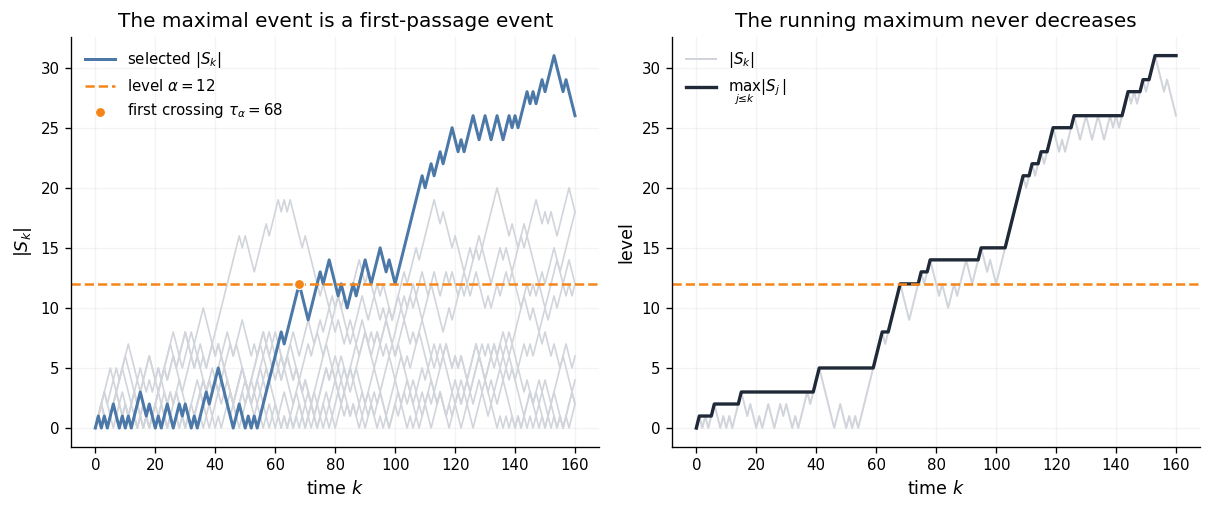

In [2]:
rng = np.random.default_rng(SEED + 1)
n_display_steps = 160
n_candidate_paths = 24

increments = rng.choice(
    np.array([-1, 1], dtype=np.int8),
    size=(n_candidate_paths, n_display_steps),
)
walks = np.column_stack([
    np.zeros(n_candidate_paths, dtype=np.int16),
    np.cumsum(increments, axis=1, dtype=np.int16),
])
absolute_walks = np.abs(walks)
running_maxima = np.maximum.accumulate(absolute_walks, axis=1)

selected = int(np.argmax(running_maxima[:, -1]))
display_indices = [selected] + [j for j in range(n_candidate_paths) if j != selected][:9]
alpha_path = 12
crossings = np.flatnonzero(absolute_walks[selected] >= alpha_path)
first_crossing = int(crossings[0]) if crossings.size else None
time_index = np.arange(n_display_steps + 1)

fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.35))

for j in display_indices[1:]:
    axes[0].plot(time_index, absolute_walks[j], color=LIGHT_GREY, linewidth=1.0)
axes[0].plot(
    time_index,
    absolute_walks[selected],
    color=BLUE,
    linewidth=1.8,
    label=r"selected $|S_k|$",
)
axes[0].axhline(alpha_path, color=ORANGE, linestyle="--", linewidth=1.5, label=rf"level $\alpha={alpha_path}$")
if first_crossing is not None:
    axes[0].scatter(
        first_crossing,
        absolute_walks[selected, first_crossing],
        color=ORANGE,
        edgecolor="white",
        linewidth=0.7,
        zorder=5,
        label=rf"first crossing $\tau_\alpha={first_crossing}$",
    )
axes[0].set_title("The maximal event is a first-passage event")
axes[0].set_xlabel(r"time $k$")
axes[0].set_ylabel(r"$|S_k|$")
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.14)

axes[1].plot(time_index, absolute_walks[selected], color=LIGHT_GREY, linewidth=1.2, label=r"$|S_k|$")
axes[1].plot(time_index, running_maxima[selected], color=INK, linewidth=2.0, label=r"$\max_{j\leq k}|S_j|$")
axes[1].axhline(alpha_path, color=ORANGE, linestyle="--", linewidth=1.5)
axes[1].set_title("The running maximum never decreases")
axes[1].set_xlabel(r"time $k$")
axes[1].set_ylabel("level")
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.14)

plt.tight_layout()
plt.show()

<p class="figure-caption"><strong>Figure 1.</strong> Absolute symmetric random walks, a first crossing of $\alpha=12$, and the associated running maximum.</p>

<p class="figure-interpretation"><span class="interpretation-label">Interpretation.</span> Once the selected path first reaches the threshold, its terminal running maximum remains above that threshold even if the path later moves back toward zero. This is the stopping-time mechanism behind the maximal inequality.</p>

## 2. The weak maximal inequality

For every $\alpha>0$, Doob's maximal inequality states

$$
\alpha\,P(M_n^*\geq\alpha)
\leq E\!\left[M_n\mathbf 1_{\{M_n^*\geq\alpha\}}\right]
\leq E[M_n].
$$

To see the first inequality, let

$$
A_k=\{M_0<\alpha,\ldots,M_{k-1}<\alpha,M_k\geq\alpha\}.
$$

The events $A_0,\ldots,A_n$ are disjoint, $A_k\in\mathcal F_k$, and their union is $\{M_n^*\geq\alpha\}$. Since $M_k\geq\alpha$ on $A_k$ and $M$ is a submartingale,

$$
\alpha P(A_k)
\leq E[M_k\mathbf 1_{A_k}]
\leq E[M_n\mathbf 1_{A_k}].
$$

Summing over $k$ proves the result. For a martingale $S$, applying the theorem to $M_k=|S_k|$ gives

$$
P\!\left(\max_{0\leq k\leq n}|S_k|\geq\alpha\right)
\leq \frac{E|S_n|}{\alpha}.
$$

Simulated paths: 160,000; steps per path: 400
Monte Carlo E|S_n|: 15.95825
Largest tail-probability standard error: 0.00125


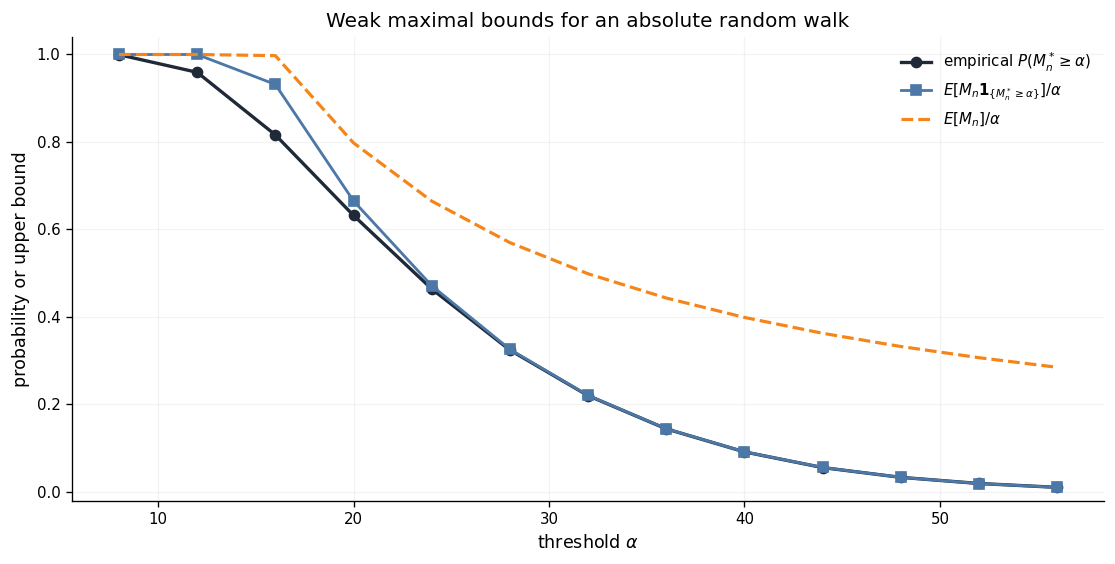

In [3]:
rng = np.random.default_rng(SEED + 2)
n_steps = 400
n_paths = 160_000

terminal_abs, maximal_abs = random_walk_terminal_and_max(
    n_steps,
    n_paths,
    rng,
)

alpha_grid = np.arange(8, 57, 4)
empirical_tail = np.array([
    np.mean(maximal_abs >= alpha) for alpha in alpha_grid
])
refined_bound = np.array([
    np.mean(terminal_abs * (maximal_abs >= alpha)) / alpha
    for alpha in alpha_grid
])
coarse_bound = terminal_abs.mean() / alpha_grid
standard_error = np.sqrt(empirical_tail * (1.0 - empirical_tail) / n_paths)

print(f"Simulated paths: {n_paths:,}; steps per path: {n_steps}")
print(f"Monte Carlo E|S_n|: {terminal_abs.mean():.5f}")
print(f"Largest tail-probability standard error: {standard_error.max():.5f}")

fig, ax = plt.subplots(figsize=(9.4, 4.8))
ax.plot(
    alpha_grid,
    empirical_tail,
    marker="o",
    color=INK,
    linewidth=2.0,
    label=r"empirical $P(M_n^*\geq\alpha)$",
)
ax.plot(
    alpha_grid,
    np.minimum(1.0, refined_bound),
    marker="s",
    color=BLUE,
    linewidth=1.7,
    label=r"$E[M_n\mathbf{1}_{\{M_n^*\geq\alpha\}}]/\alpha$",
)
ax.plot(
    alpha_grid,
    np.minimum(1.0, coarse_bound),
    linestyle="--",
    color=ORANGE,
    linewidth=1.9,
    label=r"$E[M_n]/\alpha$",
)
ax.set_title("Weak maximal bounds for an absolute random walk")
ax.set_xlabel(r"threshold $\alpha$")
ax.set_ylabel("probability or upper bound")
ax.set_ylim(-0.02, 1.04)
ax.legend(frameon=False)
ax.grid(alpha=0.14)
plt.tight_layout()
plt.show()

<p class="figure-caption"><strong>Figure 2.</strong> Monte Carlo estimates of the maximal tail probability and the two bounds in Doob's weak inequality for $M_k=|S_k|$ over $400$ steps.</p>

<p class="figure-interpretation"><span class="interpretation-label">Interpretation.</span> The event-specific expectation retains information about paths that cross the threshold and is therefore sharper than the bound using only $E[M_n]$. The plotted bounds are clipped at one because probabilities cannot exceed one. Simulation illustrates the ordering; the theorem itself follows from the first-crossing argument above.</p>

## 3. The strong $L^p$ inequality

If $p\in(1,\infty)$ and $M$ is a non-negative submartingale, then

$$
\|M_n^*\|_p
\leq \frac{p}{p-1}\,\|M_n\|_p.
$$

The constant becomes large as $p\downarrow1$, which is consistent with the absence of a corresponding strong $L^1$ inequality. The proof combines the refined weak inequality with the layer-cake identity:

$$
\begin{aligned}
E[(M_n^*)^p]
&=\int_0^\infty p\alpha^{p-1}P(M_n^*\geq\alpha)\,d\alpha\\
&\leq \frac{p}{p-1}E\!\left[M_n(M_n^*)^{p-1}\right]\\
&\leq \frac{p}{p-1}\|M_n\|_p\|M_n^*\|_p^{p-1},
\end{aligned}
$$

where the final step is Hölder's inequality. Dividing by $\|M_n^*\|_p^{p-1}$ gives the result. In particular,

$$
E[(M_n^*)^2]\leq4E[M_n^2].
$$

For a real-valued martingale $S$, take $M_k=|S_k|$.

 p     empirical ratio     Doob constant
1.2         1.4843            6.0000
1.5         1.4154            3.0000
2.0         1.3316            2.0000
3.0         1.2294            1.5000
4.0         1.1717            1.3333
6.0         1.1128            1.2000


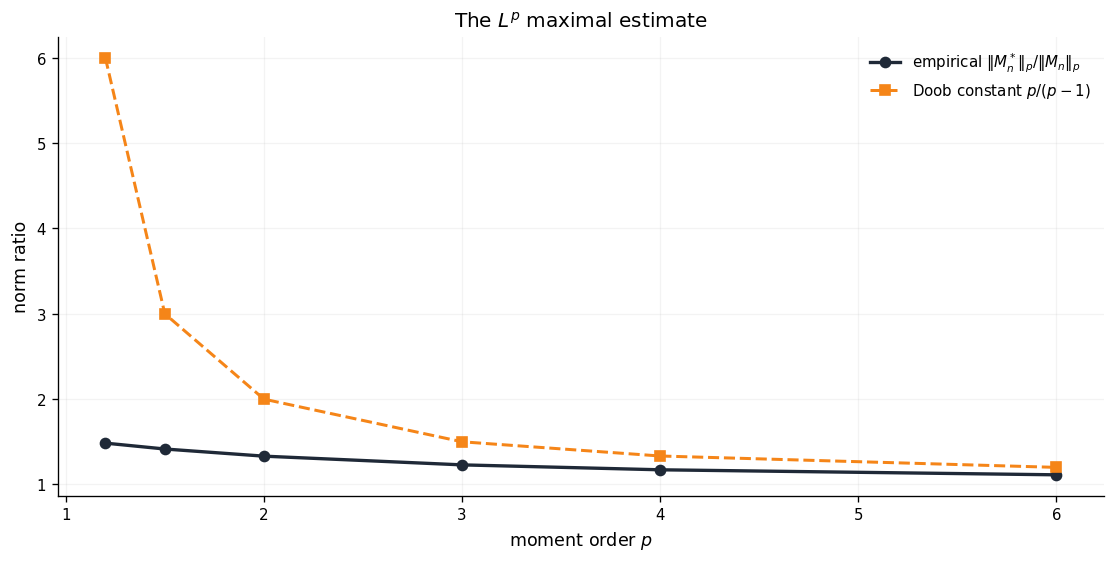

In [4]:
p_grid = np.array([1.2, 1.5, 2.0, 3.0, 4.0, 6.0])
empirical_ratios = np.array([
    np.mean(maximal_abs.astype(float) ** p) ** (1.0 / p)
    / np.mean(terminal_abs.astype(float) ** p) ** (1.0 / p)
    for p in p_grid
])
doob_constants = p_grid / (p_grid - 1.0)

print(" p     empirical ratio     Doob constant")
for p, ratio, constant in zip(p_grid, empirical_ratios, doob_constants):
    print(f"{p:>3.1f}       {ratio:>8.4f}          {constant:>8.4f}")

fig, ax = plt.subplots(figsize=(9.4, 4.8))
ax.plot(
    p_grid,
    empirical_ratios,
    marker="o",
    color=INK,
    linewidth=2.0,
    label=r"empirical $\|M_n^*\|_p/\|M_n\|_p$",
)
ax.plot(
    p_grid,
    doob_constants,
    marker="s",
    linestyle="--",
    color=ORANGE,
    linewidth=1.8,
    label=r"Doob constant $p/(p-1)$",
)
ax.set_title(r"The $L^p$ maximal estimate")
ax.set_xlabel(r"moment order $p$")
ax.set_ylabel("norm ratio")
ax.legend(frameon=False)
ax.grid(alpha=0.14)
plt.tight_layout()
plt.show()

<p class="figure-caption"><strong>Figure 3.</strong> Empirical $L^p$ norm ratios for the same absolute random walk, compared with the universal constant $p/(p-1)$.</p>

<p class="figure-interpretation"><span class="interpretation-label">Interpretation.</span> The simulated ratios lie below the theoretical constants, but the gap should not be read as a better universal theorem: Doob's constant must control every admissible submartingale. The rapid increase near $p=1$ identifies the endpoint where the strong estimate breaks down.</p>

## 4. Continuous time through nested grids

Let $(M_t)_{0\leq t\leq T}$ be a non-negative continuous submartingale and set

$$
M_T^*=\sup_{0\leq t\leq T}M_t.
$$

For $\alpha>0$ and $p\in(1,\infty)$,

$$
\alpha P(M_T^*\geq\alpha)
\leq E\!\left[M_T\mathbf 1_{\{M_T^*\geq\alpha\}}\right]
\leq E[M_T],
$$

and

$$
\|M_T^*\|_p\leq\frac{p}{p-1}\|M_T\|_p.
$$

Apply the discrete-time inequalities on the nested dyadic grids

$$
D_m=\{jT/2^m:0\leq j\leq2^m\}.
$$

Continuity implies

$$
\max_{t\in D_m}M_t\uparrow\sup_{0\leq t\leq T}M_t.
$$

For the weak inequality, apply the discrete result at a level just below $\alpha$, refine the grid, and then let that level increase to $\alpha$. Fatou's lemma passes the $L^p$ estimate to the limit. For a continuous martingale that may change sign, apply the result to $|M_t|$.

Fine-grid maximum: 1.386646
Nested-grid maxima: 1.307458, 1.307458, 1.307458, 1.346116, 1.380493, 1.386646


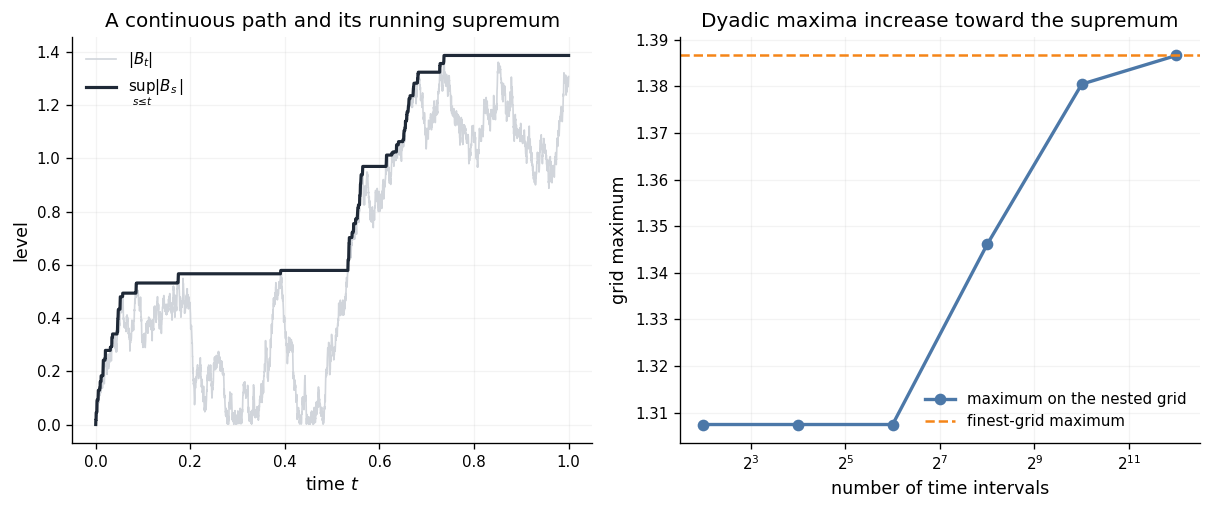

In [5]:
rng = np.random.default_rng(SEED + 3)
T = 1.0
fine_steps = 4096
dt = T / fine_steps

brownian_path = np.concatenate([
    [0.0],
    np.cumsum(rng.standard_normal(fine_steps) * np.sqrt(dt)),
])
absolute_brownian = np.abs(brownian_path)
running_supremum = np.maximum.accumulate(absolute_brownian)
fine_time = np.linspace(0.0, T, fine_steps + 1)

grid_sizes = np.array([4, 16, 64, 256, 1024, 4096])
grid_maxima = np.array([
    absolute_brownian[:: fine_steps // grid_size].max()
    for grid_size in grid_sizes
])

print(f"Fine-grid maximum: {grid_maxima[-1]:.6f}")
print("Nested-grid maxima: " + ", ".join(f"{value:.6f}" for value in grid_maxima))

fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.35))

axes[0].plot(fine_time, absolute_brownian, color=LIGHT_GREY, linewidth=1.0, label=r"$|B_t|$")
axes[0].plot(fine_time, running_supremum, color=INK, linewidth=1.9, label=r"$\sup_{s\leq t}|B_s|$")
axes[0].set_title("A continuous path and its running supremum")
axes[0].set_xlabel(r"time $t$")
axes[0].set_ylabel("level")
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.14)

axes[1].plot(
    grid_sizes,
    grid_maxima,
    marker="o",
    color=BLUE,
    linewidth=2.0,
    label="maximum on the nested grid",
)
axes[1].axhline(
    grid_maxima[-1],
    color=ORANGE,
    linestyle="--",
    linewidth=1.5,
    label="finest-grid maximum",
)
axes[1].set_xscale("log", base=2)
axes[1].set_title("Dyadic maxima increase toward the supremum")
axes[1].set_xlabel("number of time intervals")
axes[1].set_ylabel("grid maximum")
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.14)

plt.tight_layout()
plt.show()

<p class="figure-caption"><strong>Figure 4.</strong> A Brownian sample path and the maxima observed on increasingly fine nested dyadic grids.</p>

<p class="figure-interpretation"><span class="interpretation-label">Interpretation.</span> Coarse grids can miss an excursion between observation times. Because the path is continuous and the grids are nested and dense, their maxima increase to the full path supremum. This is the bridge from the discrete theorem to its continuous-time form.</p>

## 5. From terminal $L^2$ error to uniform path control

Let $f\in L^2([0,T])$, let $(f_N)$ be deterministic step functions converging to $f$ in $L^2([0,T])$, and define

$$
X_t^{(N)}=\int_0^t f_N(s)\,dB_s.
$$

For two resolutions $N_1$ and $N_2$, the difference

$$
\Delta_t=X_t^{(N_1)}-X_t^{(N_2)}
=\int_0^t\bigl(f_{N_1}(s)-f_{N_2}(s)\bigr)\,dB_s
$$

is a square-integrable martingale. Since $|\Delta_t|^2$ is a non-negative submartingale, the weak maximal inequality and Itô isometry give

$$
P\!\left(\sup_{0\leq t\leq T}|\Delta_t|\geq\varepsilon\right)
\leq\frac{E|\Delta_T|^2}{\varepsilon^2}
=\frac{1}{\varepsilon^2}
\int_0^T|f_{N_1}(s)-f_{N_2}(s)|^2\,ds.
$$

The strong $L^2$ inequality is a different statement:

$$
E\!\left[\sup_{0\leq t\leq T}|\Delta_t|^2\right]
\leq4E|\Delta_T|^2.
$$

The probability bound has constant $1$ because the weak inequality is applied directly to $|\Delta|^2$ at level $\varepsilon^2$; squaring the strong $L^2$ norm inequality instead gives the constant $4$.

The experiment below uses left-endpoint approximations of the smooth function $f(t)=0.7+0.3\sin(6\pi t)$, for which the required $L^2$ convergence is immediate.

Exact E|Delta_T|^2:             0.012987
Monte Carlo E|Delta_T|^2:       0.012983
Monte Carlo E[sup |Delta_t|^2]: 0.022818
Strong L2 upper bound:           0.051948


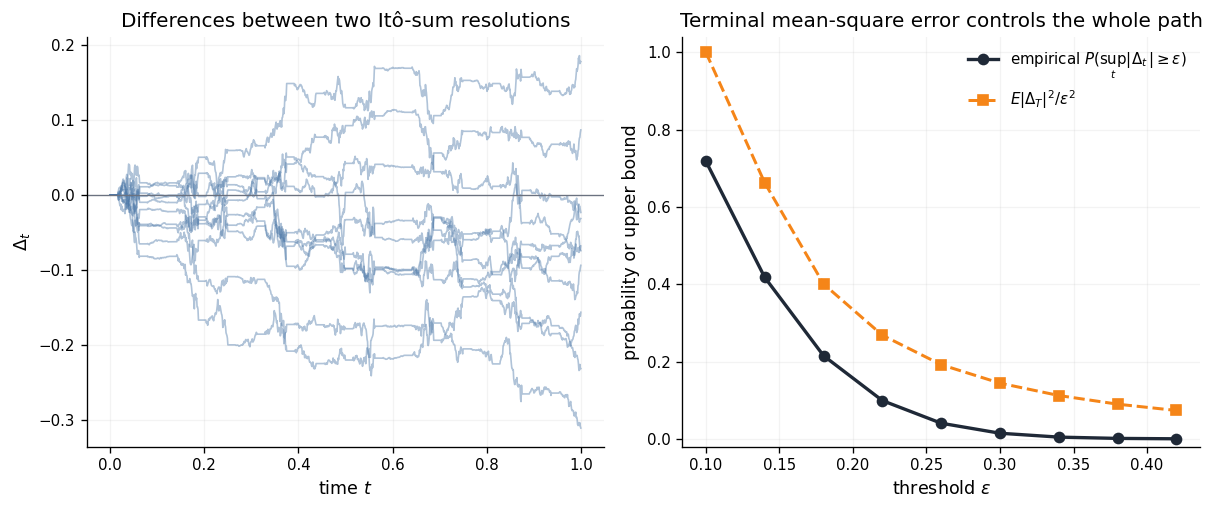

In [6]:
rng = np.random.default_rng(SEED + 4)
T = 1.0
n_fine = 1024
N_coarse = 16
N_fine_approx = 64
n_ito_paths = 40_000
chunk_size = 4_000

dt = T / n_fine
left_times = np.arange(n_fine) * dt
coarse_values = deterministic_integrand(
    np.floor(left_times * N_coarse) / N_coarse
)
fine_values = deterministic_integrand(
    np.floor(left_times * N_fine_approx) / N_fine_approx
)
coefficient_difference = coarse_values - fine_values
exact_terminal_variance = np.sum(coefficient_difference**2) * dt

terminal_differences = np.empty(n_ito_paths)
maximal_differences = np.empty(n_ito_paths)
sample_difference_paths = None

for start in range(0, n_ito_paths, chunk_size):
    stop = min(start + chunk_size, n_ito_paths)
    delta_paths = rng.standard_normal((stop - start, n_fine))
    delta_paths *= np.sqrt(dt) * coefficient_difference
    np.cumsum(delta_paths, axis=1, out=delta_paths)

    terminal_differences[start:stop] = delta_paths[:, -1]
    maximal_differences[start:stop] = np.max(np.abs(delta_paths), axis=1)

    if sample_difference_paths is None:
        sample_difference_paths = np.column_stack([
            np.zeros(10),
            delta_paths[:10].copy(),
        ])

epsilon_grid = np.linspace(0.10, 0.42, 9)
empirical_ito_tail = np.array([
    np.mean(maximal_differences >= epsilon)
    for epsilon in epsilon_grid
])
weak_ito_bound = np.minimum(1.0, exact_terminal_variance / epsilon_grid**2)
empirical_terminal_variance = np.mean(terminal_differences**2)
empirical_maximal_second_moment = np.mean(maximal_differences**2)

print(f"Exact E|Delta_T|^2:             {exact_terminal_variance:.6f}")
print(f"Monte Carlo E|Delta_T|^2:       {empirical_terminal_variance:.6f}")
print(f"Monte Carlo E[sup |Delta_t|^2]: {empirical_maximal_second_moment:.6f}")
print(f"Strong L2 upper bound:           {4.0 * exact_terminal_variance:.6f}")

ito_time = np.linspace(0.0, T, n_fine + 1)
fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.35))

for path in sample_difference_paths:
    axes[0].plot(ito_time, path, color=BLUE, alpha=0.44, linewidth=1.0)
axes[0].axhline(0.0, color=GREY, linewidth=0.8)
axes[0].set_title("Differences between two Itô-sum resolutions")
axes[0].set_xlabel(r"time $t$")
axes[0].set_ylabel(r"$\Delta_t$")
axes[0].grid(alpha=0.14)

axes[1].plot(
    epsilon_grid,
    empirical_ito_tail,
    marker="o",
    color=INK,
    linewidth=2.0,
    label=r"empirical $P(\sup_t|\Delta_t|\geq\varepsilon)$",
)
axes[1].plot(
    epsilon_grid,
    weak_ito_bound,
    marker="s",
    linestyle="--",
    color=ORANGE,
    linewidth=1.8,
    label=r"$E|\Delta_T|^2/\varepsilon^2$",
)
axes[1].set_title("Terminal mean-square error controls the whole path")
axes[1].set_xlabel(r"threshold $\varepsilon$")
axes[1].set_ylabel("probability or upper bound")
axes[1].set_ylim(-0.02, 1.04)
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.14)

plt.tight_layout()
plt.show()

<p class="figure-caption"><strong>Figure 5.</strong> Differences between stochastic integrals using $16$ and $64$ left-endpoint approximations, together with the weak maximal bound based on the exact terminal variance.</p>

<p class="figure-interpretation"><span class="interpretation-label">Interpretation.</span> Itô isometry converts approximation error of the deterministic integrands into terminal mean-square error. Doob's weak inequality then turns that terminal quantity into a bound for the largest error over the entire time interval. This is supremum-in-time control in probability, the form used in constructing the Itô integral process.</p>

## References

- *MATH3015: Stochastic Processes*, Chapter 2, Theorems 2.15 and 2.17; Chapter 3, Theorem 3.14; Chapter 4, Section 4.1.
- Fima C. Klebaner, *Introduction to Stochastic Calculus with Applications*, 3rd ed., Chapter 7, Theorem 7.31.